# EDA — Financial News Sentiment & Market Signal

## Context
In the previous notebook (01_data_collection.ipynb), we merged two datasets: Yahoo Finance RSS headlines labeled by FinBERT, and the Financial PhraseBank dataset manually labeled by financial experts. The merged dataset contains 4,933 rows — 4,846 from Financial PhraseBank and 87 from RSS feeds (after filtering out low-confidence FinBERT labels below the 0.75 threshold).

## Sentiment distribution:
Neutral: 2,935 (59%)
Positive: 1,375 (28%)
Negative: 623 (13%)

This confirms a class imbalance that will need to be addressed in modeling.

## Analytical Agenda
This EDA phase investigates four key questions:

Is the label distribution balanced across the full dataset?
Are the two sources homogeneous in terms of text length, structure, and vocabulary?
Is there label consistency within each source?
Are there data quality issues — null values, duplicates, or empty strings?

Findings here will determine what preprocessing decisions are needed before feature engineering and model development.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/merged_dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Shape: (4933, 5)

Data types:
title                  str
sentiment_label        str
sentiment_score    float64
low_confidence        bool
source                 str
dtype: object

First 5 rows:
                                               title sentiment_label  \
0  According to Gran , the company has no plans t...         neutral   
1  Technopolis plans to develop in stages an area...         neutral   
2  The international electronic industry company ...        negative   
3  With the new production plant the company woul...        positive   
4  According to the company 's updated strategy f...        positive   

   sentiment_score  low_confidence                source  
0              1.0           False  financial_phrasebank  
1              1.0           False  financial_phrasebank  
2              1.0           False  financial_phrasebank  
3              1.0           False  financial_phrasebank  
4              1.0           False  financial_phrasebank  


In [14]:
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nEmpty strings in title: {(df['title'].str.strip() == '').sum()}")

Null values:
title              0
sentiment_label    0
sentiment_score    0
low_confidence     0
source             0
dtype: int64

Duplicate rows: 11

Empty strings in title: 0


In [15]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 4922


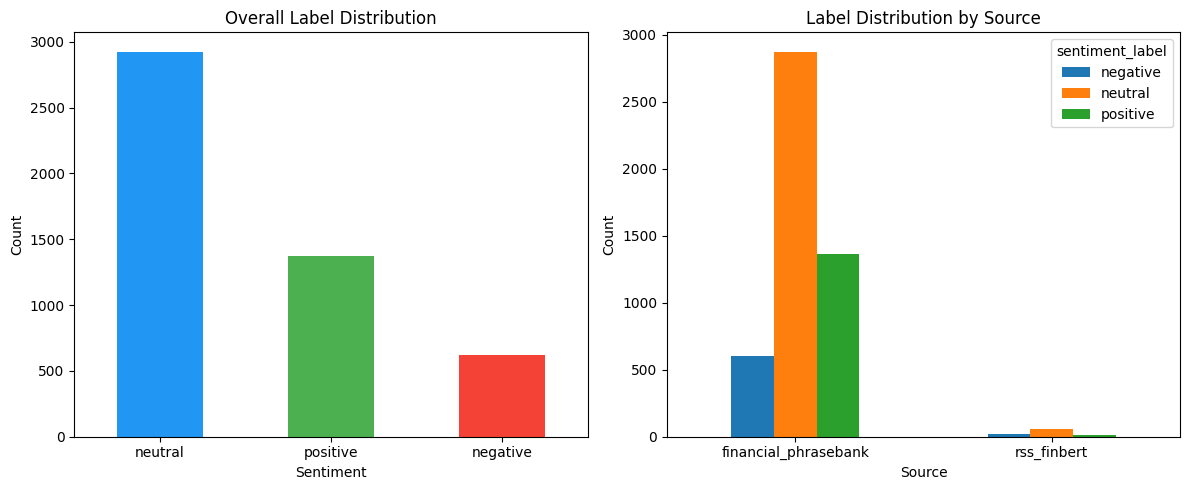

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall distribution
df['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#F44336']
)
axes[0].set_title('Overall Label Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Distribution by source
df.groupby(['source', 'sentiment_label']).size().unstack().plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Label Distribution by Source')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Text length statistics by source:
                       count       mean       std  min   25%   50%    75%  \
source                                                                      
financial_phrasebank  4840.0  23.092975  9.940827  2.0  16.0  21.0  29.00   
rss_finbert             82.0  10.890244  3.627760  4.0   8.0  10.5  13.75   

                       max  
source                      
financial_phrasebank  81.0  
rss_finbert           21.0  


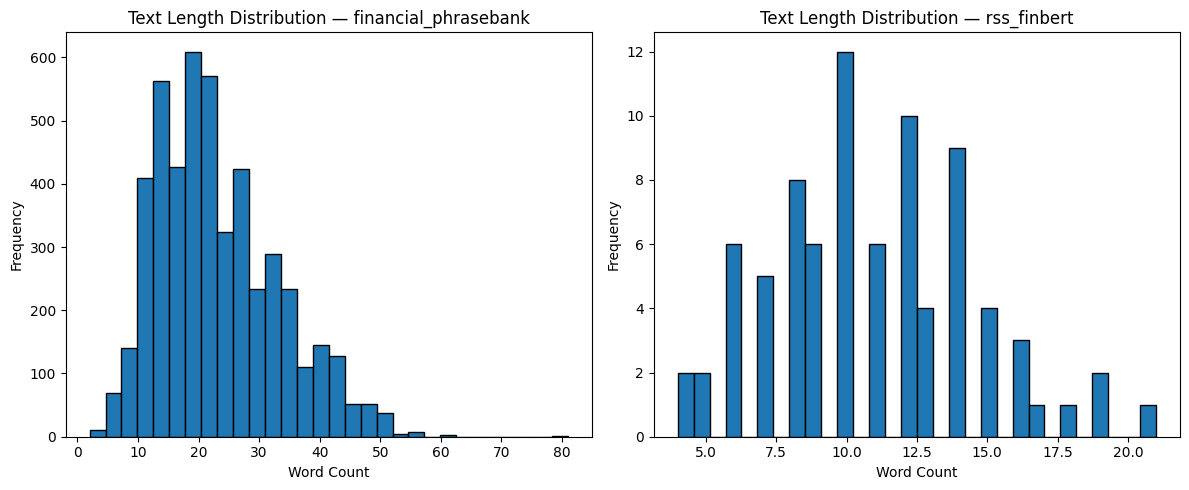

In [17]:
df['text_length'] = df['title'].str.split().str.len()

print("Text length statistics by source:")
print(df.groupby('source')['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (source, group) in zip(axes, df.groupby('source')):
    ax.hist(group['text_length'], bins=30, edgecolor='black')
    ax.set_title(f'Text Length Distribution — {source}')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Short sentences produce sparse feature vectors under TF-IDF because they contain fewer words. The model sees less signal per RSS row compared to PhraseBank rows. Combined with the fact that RSS is only 1.6% of the data, those rows contribute very little and very noisy signal.
PhraseBank is the foundation, RSS is supplementary.

In [18]:
print("Label distribution by source (%):")
print(df.groupby('source')['sentiment_label']
    .value_counts(normalize=True)
    .mul(100)
    .round(1))

Label distribution by source (%):
source                sentiment_label
financial_phrasebank  neutral            59.4
                      positive           28.2
                      negative           12.5
rss_finbert           neutral            64.6
                      negative           20.7
                      positive           14.6
Name: proportion, dtype: float64


News headlines are written to grab attention — they amplify negative events because bad news drives clicks. Earnings reports and analyst notes use measured, professional language that tends toward neutral or cautiously positive framing. This is a real structural difference between the two sources that explains the label shift.

In [19]:
# Check for very short titles that may not carry enough signal
print("Titles with fewer than 4 words:")
print(df[df['text_length'] < 4][['title', 'source', 'sentiment_label']])

# Check sentiment score distribution for RSS rows
print("\nRSS sentiment score distribution:")
print(df[df['source'] == 'rss_finbert']['sentiment_score'].describe())

Titles with fewer than 4 words:
                      title                source sentiment_label
1115              Welcome !  financial_phrasebank         neutral
2515  Net investment income  financial_phrasebank         neutral
2565        Status : Agreed  financial_phrasebank         neutral
3057         NWC ANALYSIS :  financial_phrasebank         neutral

RSS sentiment score distribution:
count    82.000000
mean      0.889746
std       0.052823
min       0.755264
25%       0.862992
50%       0.897956
75%       0.929214
max       0.972478
Name: sentiment_score, dtype: float64


In [20]:
# Save EDA-reviewed dataset (no modifications — cleaning happens in 03_preprocessing.ipynb)
df.to_csv("../data/processed/eda_reviewed.csv", index=False)
print(f"EDA complete. Dataset shape: {df.shape}")
print(f"\nKnown issues to address in preprocessing:")
print(f"- Class imbalance: neutral 59%, positive 28%, negative 13%")
print(f"- 4 titles with fewer than 4 words (fragments, no sentiment signal)")
print(f"- Text length gap between sources: PhraseBank avg 23 words, RSS avg 10 words")

EDA complete. Dataset shape: (4922, 6)

Known issues to address in preprocessing:
- Class imbalance: neutral 59%, positive 28%, negative 13%
- 4 titles with fewer than 4 words (fragments, no sentiment signal)
- Text length gap between sources: PhraseBank avg 23 words, RSS avg 10 words
